In [7]:
# Install all required packages in the current kernel
!pip install pandas numpy matplotlib geopandas shapely osmnx networkx geopy ipykernel


In [16]:
# Cell 2: Complete Imports - exactly like your original code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Geospatial libraries  
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, box
from shapely.ops import unary_union
import osmnx as ox
import networkx as nx

# External services (for geocoding)
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Utilities
import threading
import time
import sys
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")
print(" Ready to explore 15-minute cities in London!")

 All libraries imported successfully!
 Ready to explore 15-minute cities in London!


In [17]:
# Cell 3: London City Database - adapted from your original code
# This replaces the Paris-focused database with London locations

city_db = {
    "London_CityCenter": {
        "house_number": "",
        "street": "King William Street", 
        "city": "London",
        "postal_code": "EC4N 7AX",
        "state": "",
        "country": "UK",
        "full_address": "Bank of England, London EC2R 8AH, UK",
        "coordinates": [51.5140, -0.0885],  # Bank/City area
        "description": "Financial heart of London"
    },
    "London_Shoreditch": {
        "house_number": "1",
        "street": "Redchurch Street",
        "city": "London", 
        "postal_code": "E2 7DJ",
        "state": "",
        "country": "UK",
        "full_address": "Shoreditch High Street, London E1 6JE, UK",
        "coordinates": [51.5287, -0.0817],  # Trendy East London
        "description": "Hip creative district with great cycling infrastructure"
    },
    "London_Camden": {
        "house_number": "",
        "street": "Camden High Street",
        "city": "London",
        "postal_code": "NW1 7JE", 
        "state": "",
        "country": "UK",
        "full_address": "Camden Market, London NW1 8AF, UK",
        "coordinates": [51.5439, -0.1419],  # Camden Market area
        "description": "Cultural hub with excellent walkability"
    },
    "London_Greenwich": {
        "house_number": "",
        "street": "Romney Road",
        "city": "London",
        "postal_code": "SE10 9NF",
        "state": "",
        "country": "UK", 
        "full_address": "Royal Observatory Greenwich, London SE10 9NF, UK",
        "coordinates": [51.4769, -0.0005],  # Greenwich Observatory
        "description": "Historic area with riverside walks"
    },
    "London_Canary_Wharf": {
        "house_number": "",
        "street": "Canada Square",
        "city": "London",
        "postal_code": "E14 5AB",
        "state": "",
        "country": "UK",
        "full_address": "Canary Wharf, London E14 5AB, UK", 
        "coordinates": [51.5054, -0.0235],  # Business district
        "description": "Modern business district with planned infrastructure"
    }
}

# Display available London locations
print("🏴󠁧󠁢󠁥󠁮󠁧 Available London locations to explore:")
for key, info in city_db.items():
    lat, lon = info["coordinates"]
    print(f"   • {key}: {info['description']}")
    print(f"     📍 {lat:.4f}, {lon:.4f}")
    print()

🏴󠁧󠁢󠁥󠁮󠁧 Available London locations to explore:
   • London_CityCenter: Financial heart of London
     📍 51.5140, -0.0885

   • London_Shoreditch: Hip creative district with great cycling infrastructure
     📍 51.5287, -0.0817

   • London_Camden: Cultural hub with excellent walkability
     📍 51.5439, -0.1419

   • London_Greenwich: Historic area with riverside walks
     📍 51.4769, -0.0005

   • London_Canary_Wharf: Modern business district with planned infrastructure
     📍 51.5054, -0.0235



In [18]:
# Cell 4:  INTERACTIVE CONTROLS - Your "Slider" Section!
#  MODIFY THESE VALUES TO EXPLORE DIFFERENT SCENARIOS - This is your interactive dashboard!

#  LOCATION SELECTOR - Change this to explore different areas!
selected_city = "London_CityCenter"  # Try: London_Shoreditch, London_Camden, London_Greenwich, London_Canary_Wharf

# ⏱ TIME SLIDER - THIS IS YOUR MAIN SLIDER! 
time_minutes = 15  # 🎚️ Change from 5 to 30 minutes and see the difference!

#  TRANSPORT MODE TOGGLES - Turn on/off what you want to analyze
show_walking = True   # 🚶‍♂️ Set to False to hide walking
show_cycling = True   # 🚴‍♂️ Set to False to hide cycling  
show_driving = True   # 🚗 Set to False to hide driving

# ⚡ SPEED SETTINGS (km/h) - Adjust realistic London speeds
walking_speed = 5     # 🎚️ Try 3-8 km/h (London walking pace)
cycling_speed = 15    # 🎚️ Try 10-20 km/h (London cycling with traffic)
driving_speed = 25    # 🎚️ Try 15-35 km/h (London traffic is SLOW!)

#  VISUALIZATION SETTINGS (from your original code)
draw_buffers = True   # Set to False for cleaner look
save_map = False      # Set to True to save the final map

# ===== EXECUTION SECTION =====
# Get the selected location info
location = city_db[selected_city]
lat, lon = location["coordinates"]
location_name = f"{location['city']} ({location['country']})"

print(" CURRENT ANALYSIS SETTINGS:")
print("=" * 50)
print(f" Location: {selected_city}")
print(f"  Area: {location['description']}")  
print(f" Coordinates: {lat:.4f}, {lon:.4f}")
print(f"⏱  Time limit: {time_minutes} minutes")
print()
print("🚊 Transport modes:")
print(f"   🚶‍♂️ Walking: {walking_speed} km/h ({'✅ ON' if show_walking else '❌ OFF'})")
print(f"   🚴‍♂️ Cycling: {cycling_speed} km/h ({'✅ ON' if show_cycling else '❌ OFF'})")
print(f"   🚗 Driving: {driving_speed} km/h ({'✅ ON' if show_driving else '❌ OFF'})")
print()
print("💡 TIP: Change the values above and re-run this cell to update settings!")

 CURRENT ANALYSIS SETTINGS:
 Location: London_CityCenter
  Area: Financial heart of London
 Coordinates: 51.5140, -0.0885
⏱  Time limit: 15 minutes

🚊 Transport modes:
   🚶‍♂️ Walking: 5 km/h (✅ ON)
   🚴‍♂️ Cycling: 15 km/h (✅ ON)
   🚗 Driving: 25 km/h (✅ ON)

💡 TIP: Change the values above and re-run this cell to update settings!


In [19]:
# Cell 5: Helper Functions - adapted from your original code

def spinner(stop_event):
    """Spinning progress indicator while downloading"""
    symbols = ["|", "/", "-", "\\"]
    idx = 0
    while not stop_event.is_set():
        sys.stdout.write("\rDownloading from Overpass... " + symbols[idx % len(symbols)])
        sys.stdout.flush()
        idx += 1
        time.sleep(0.1)
    # clear line when done
    sys.stdout.write("\rDownload complete ✅          \n")
    sys.stdout.flush()

def download_with_spinner(center_point, dist=2000, network_type="drive"):
    """Download network with spinning progress indicator"""
    stop_event = threading.Event()
    thread = threading.Thread(target=spinner, args=(stop_event,))
    thread.start()

    # --- actual download ---
    G = ox.graph_from_point(center_point, dist=dist, network_type=network_type)

    # stop spinner
    stop_event.set()
    thread.join()
    return G

def download_with_timer(origin_point, dist, network_type="drive"):
    """Download network with timer - from your original code"""
    start_time = time.time()

    # Download the network
    G = download_with_spinner(origin_point, dist=dist, network_type=network_type)

    elapsed = time.time() - start_time
    print(f"Network ({network_type}) extracted in {elapsed:.2f} seconds.")

    return G

def create_outer_boundary(reachable_subgraph: nx.Graph) -> gpd.GeoSeries:
    """
    Create a clean outer boundary polygon of a reachable subgraph.
    From your original code - exactly the same logic!
    """
    # Extract edge geometries
    edge_geoms = [
        data["geometry"] if "geometry" in data else
        LineString([
            (reachable_subgraph.nodes[u]["x"], reachable_subgraph.nodes[u]["y"]),
            (reachable_subgraph.nodes[v]["x"], reachable_subgraph.nodes[v]["y"])
        ])
        for u, v, data in reachable_subgraph.edges(data=True)
    ]

    gdf_edges = gpd.GeoDataFrame(geometry=edge_geoms, crs="EPSG:4326")

    # Project to UTM for metric buffering
    utm_crs = gdf_edges.estimate_utm_crs()
    gdf_edges_utm = gdf_edges.to_crs(utm_crs)

    # Buffer edges (half segment length + 10 meters)
    buffer_sizes = gdf_edges_utm.length / 2 + 10
    buffered_edges = gdf_edges_utm.buffer(buffer_sizes)

    # Dissolve into a single polygon
    network_polygon = unary_union(buffered_edges)

    # Keep only the exterior boundary (remove holes)
    if network_polygon.geom_type == "MultiPolygon":
        # Keep largest polygon
        largest_poly = max(network_polygon.geoms, key=lambda p: p.area)
    else:
        largest_poly = network_polygon

    exterior_line = largest_poly.exterior
    network_polygon_clean = Polygon(exterior_line)

    # Convert back to WGS84
    network_polygon_wgs_clean = gpd.GeoSeries([network_polygon_clean], crs=utm_crs).to_crs("EPSG:4326")

    return network_polygon_wgs_clean

def get_reachable_subgraph(
    G: nx.Graph,
    center_node: int,
    travel_speed: float = 35,
    node_penalty: float = 0.25,
):
    """
    Compute reachable subgraph around origin point based on travel time.
    From your original code with same logic!
    """
    # Add travel time to edges
    meters_per_minute = travel_speed * 1000 / 60
    for u, v, k, data in G.edges(keys=True, data=True):
        edge_time = data['length'] / meters_per_minute
        data['time'] = edge_time + node_penalty

    # Reachable subgraph for the time limit
    reachable_subgraph = nx.ego_graph(G, center_node, radius=time_minutes, distance='time')

    return reachable_subgraph

print("🔧 Helper functions loaded successfully!")
print("📡 Ready to download London street networks!")

🔧 Helper functions loaded successfully!
📡 Ready to download London street networks!


📍 Origin point: [51.514, -0.0885]
🏙️  Downloading networks for Financial heart of London

🚶‍♂️ Downloading WALKING network...
Download complete ✅          -
Network (walk) extracted in 6.37 seconds.
   → Walking network: 8915 nodes, 23306 edges

🚴‍♂️ Downloading CYCLING network...
Download complete ✅          \
Network (bike) extracted in 27.78 seconds.
   → Cycling network: 53345 nodes, 121036 edges

🚗 Downloading DRIVING network...
Download complete ✅          |
Network (drive) extracted in 34.24 seconds.
   → Driving network: 48804 nodes, 113842 edges

🎉 Successfully downloaded 3 network(s) for London!
⚡ Ready for reachability analysis!


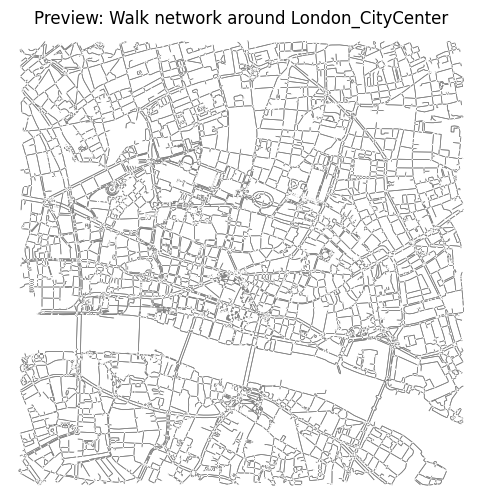

In [20]:
# Cell 6: Download Street Networks - adapted from your original code

# Search radius for downloading networks (meters) - from your original code
search_dist_drive = 10000  # 10 km radius (~max 15-minute car distance in city)
search_dist_bike = 6250    # ~6.25 km radius (~max 15-minute bike distance + buffer)  
search_dist_walk = 1500    # 1.5 km radius (~max 15-minute walk distance + small buffer)

# Create origin point (lat, lon) for the downloads
origin_point = [lat, lon]
print(f"📍 Origin point: {origin_point}")
print(f"🏙️  Downloading networks for {location['description']}")
print()

# Download networks based on your settings from Cell 4
networks = {}

if show_walking:
    print("🚶‍♂️ Downloading WALKING network...")
    networks['walk'] = download_with_timer(origin_point, dist=search_dist_walk, network_type="walk")
    print(f"   → Walking network: {len(networks['walk'].nodes)} nodes, {len(networks['walk'].edges)} edges")
    print()

if show_cycling:
    print("🚴‍♂️ Downloading CYCLING network...")
    networks['bike'] = download_with_timer(origin_point, dist=search_dist_bike, network_type="bike")
    print(f"   → Cycling network: {len(networks['bike'].nodes)} nodes, {len(networks['bike'].edges)} edges")
    print()

if show_driving:
    print("🚗 Downloading DRIVING network...")
    networks['drive'] = download_with_timer(origin_point, dist=search_dist_drive, network_type="drive")
    print(f"   → Driving network: {len(networks['drive'].nodes)} nodes, {len(networks['drive'].edges)} edges")
    print()

print(f"🎉 Successfully downloaded {len(networks)} network(s) for London!")
print("⚡ Ready for reachability analysis!")

# Quick preview plot (optional)
if networks:
    # Show a quick plot of one network to verify download
    sample_network = list(networks.values())[0]
    sample_name = list(networks.keys())[0]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ox.plot_graph(sample_network, ax=ax, node_size=1, edge_color='gray', 
                  edge_linewidth=0.5, show=False, close=False)
    ax.set_title(f"Preview: {sample_name.title()} network around {selected_city}")
    plt.show()

In [21]:
# Cell 7: Calculate Reachable Areas - from your original code logic

# Convert origin point to shapely Point for distance calculations
if hasattr(origin_point, "x") and hasattr(origin_point, "y"):
    origin_point_shapely = origin_point
else:
    origin_point_shapely = Point(origin_point[1], origin_point[0])  # Point(lon, lat)

print(f"🎯 Calculating {time_minutes}-minute reachable areas...")
print(f"📍 Origin: {origin_point_shapely.x:.4f}, {origin_point_shapely.y:.4f}")
print()

# Store results for each transport mode
results = {}

# 🚶‍♂️ WALKING ANALYSIS
if show_walking and 'walk' in networks:
    print(f"🚶‍♂️ Analyzing WALKING accessibility ({walking_speed} km/h)...")
    
    # Find nearest node to origin
    center_walk = ox.distance.nearest_nodes(networks['walk'], X=origin_point_shapely.x, Y=origin_point_shapely.y)
    
    # Calculate reachable subgraph (from your original code)
    reachable_subgraph_walk = get_reachable_subgraph(
        networks['walk'], center_walk, 
        travel_speed=walking_speed, 
        node_penalty=0.01  # 0.01 min penalty per intersection for walking
    )
    
    # Create boundary polygon
    outer_boundary_walk = create_outer_boundary(reachable_subgraph_walk)
    
    results['walking'] = {
        'network': networks['walk'],
        'center': center_walk,
        'reachable': reachable_subgraph_walk,
        'boundary': outer_boundary_walk,
        'color': 'green'  # From your original code
    }
    print(f"   ✅ Walking: {len(reachable_subgraph_walk.nodes)} reachable nodes")

# 🚴‍♂️ CYCLING ANALYSIS  
if show_cycling and 'bike' in networks:
    print(f"🚴‍♂️ Analyzing CYCLING accessibility ({cycling_speed} km/h)...")
    
    center_bike = ox.distance.nearest_nodes(networks['bike'], X=origin_point_shapely.x, Y=origin_point_shapely.y)
    
    # Cycling: penalty for intersections in London traffic
    reachable_subgraph_bike = get_reachable_subgraph(
        networks['bike'], center_bike, 
        travel_speed=cycling_speed, 
        node_penalty=0.05  # 0.05 min penalty per intersection for cycling
    )
    
    outer_boundary_bike = create_outer_boundary(reachable_subgraph_bike)
    
    results['cycling'] = {
        'network': networks['bike'],
        'center': center_bike,
        'reachable': reachable_subgraph_bike,
        'boundary': outer_boundary_bike,
        'color': 'blue'  # From your original code
    }
    print(f"   ✅ Cycling: {len(reachable_subgraph_bike.nodes)} reachable nodes")

# 🚗 DRIVING ANALYSIS
if show_driving and 'drive' in networks:
    print(f"🚗 Analyzing DRIVING accessibility ({driving_speed} km/h)...")
    
    center_drive = ox.distance.nearest_nodes(networks['drive'], X=origin_point_shapely.x, Y=origin_point_shapely.y)
    
    # Driving: higher penalty for London traffic/lights
    reachable_subgraph_drive = get_reachable_subgraph(
        networks['drive'], center_drive, 
        travel_speed=driving_speed, 
        node_penalty=0.25  # 0.25 min penalty per intersection for driving
    )
    
    outer_boundary_drive = create_outer_boundary(reachable_subgraph_drive)
    
    results['driving'] = {
        'network': networks['drive'],
        'center': center_drive,
        'reachable': reachable_subgraph_drive,
        'boundary': outer_boundary_drive,
        'color': 'red'  # From your original code
    }
    print(f"   ✅ Driving: {len(reachable_subgraph_drive.nodes)} reachable nodes")

print()
print(f"🎉 Analysis complete! Calculated reachability for {len(results)} transport mode(s)")
print("🗺️  Ready to create the visualization!")

# Quick stats
for mode, data in results.items():
    if data['boundary'] is not None:
        # Rough area calculation (degrees to km²)
        area_deg2 = data['boundary'].iloc[0].area
        area_km2 = area_deg2 * 111 * 111  # Very rough conversion
        print(f"   📊 {mode.title()}: ~{area_km2:.1f} km² reachable area")

🎯 Calculating 15-minute reachable areas...
📍 Origin: -0.0885, 51.5140

🚶‍♂️ Analyzing WALKING accessibility (5 km/h)...
   ✅ Walking: 3879 reachable nodes
🚴‍♂️ Analyzing CYCLING accessibility (15 km/h)...
   ✅ Cycling: 8635 reachable nodes
🚗 Analyzing DRIVING accessibility (25 km/h)...
   ✅ Driving: 2187 reachable nodes

🎉 Analysis complete! Calculated reachability for 3 transport mode(s)
🗺️  Ready to create the visualization!
   📊 Walking: ~5.2 km² reachable area
   📊 Cycling: ~30.8 km² reachable area
   📊 Driving: ~18.9 km² reachable area


In [22]:
# Cell 8: Create the Visualization - adapted from your original plotting code

# Get graph bounds for the map extent (from your original code)
def get_graph_bounds(G):
    """Get west, east, south, north bounds of a graph - from your original code"""
    hx = [data["x"] for n, data in G.nodes(data=True)]
    hy = [data["y"] for n, data in G.nodes(data=True)]

    padding = 0.01  # degrees (~1 km in London)
    west, east = min(hx) - padding, max(hx) + padding
    south, north = min(hy) - padding, max(hy) + padding

    # Create west/east midpoints for distance calculation
    p_west = Point(west, (south + north) / 2)
    p_east = Point(east, (south + north) / 2)

    # Transform to UTM for distance
    gdf = gpd.GeoSeries([p_west, p_east], crs="EPSG:4326")
    utm_crs = gdf.estimate_utm_crs()
    gdf_utm = gdf.to_crs(utm_crs)

    # Horizontal distance in meters
    dHorizontal_m = gdf_utm[0].distance(gdf_utm[1])

    return west, east, south, north, dHorizontal_m

# Use the driving network for bounds (largest area)
if 'driving' in results:
    west, east, south, north, dHorizontal_m = get_graph_bounds(results['driving']['reachable'])
    base_network = results['driving']['network']
elif 'cycling' in results:
    west, east, south, north, dHorizontal_m = get_graph_bounds(results['cycling']['reachable'])
    base_network = results['cycling']['network']  
else:
    west, east, south, north, dHorizontal_m = get_graph_bounds(results['walking']['reachable'])
    base_network = results['walking']['network']

print(f"🗺️  Creating visualization for {selected_city}...")
print(f"📐 Map bounds: {west:.4f} to {east:.4f} (lon), {south:.4f} to {north:.4f} (lat)")
print(f"📏 Horizontal distance: {dHorizontal_m/1000:.1f} km")
print()
print("🎨 Generating the 15-minute city map...")

🗺️  Creating visualization for London_CityCenter...
📐 Map bounds: -0.1334 to -0.0500 (lon), 51.4879 to 51.5417 (lat)
📏 Horizontal distance: 5.8 km

🎨 Generating the 15-minute city map...


In [23]:
# Cell 9: Set up exactly like your original code structure

# First, add the missing get_location_name function from your original code
def get_location_name(city_id, cities_dict):
    """
    Return a formatted location name for the map title.
    From your original code - exact same function!
    """
    city_info = cities_dict.get(city_id)
    if not city_info:
        raise ValueError(f"City ID '{city_id}' not found in dictionary.")

    return f"{city_info['city']} ({city_info['country']})"

# Map our networks to your original variable names
G_drive = networks['drive'] if 'drive' in networks else None
G_bike = networks['bike'] if 'bike' in networks else None  
G_walk = networks['walk'] if 'walk' in networks else None

print("🔄 Remapping to original code structure...")
print(f"   G_drive: {'✅' if G_drive else '❌'}")
print(f"   G_bike: {'✅' if G_bike else '❌'}")
print(f"   G_walk: {'✅' if G_walk else '❌'}")

# Set up origin point exactly like your original code
if hasattr(origin_point, "x") and hasattr(origin_point, "y"):
    origin_point_shapely = origin_point
else:
    origin_point_shapely = Point(origin_point[1], origin_point[0])  # Point(lon, lat)

max_time_search = 15

print(f"📍 Origin point: {origin_point_shapely}")
print("✅ Ready for exact original reachable subgraph calculation!")

🔄 Remapping to original code structure...
   G_drive: ✅
   G_bike: ✅
   G_walk: ✅
📍 Origin point: POINT (-0.0885 51.514)
✅ Ready for exact original reachable subgraph calculation!


In [24]:
# Cell 10: EXACT reachable subgraph setup - copied from your original code

print("🎯 Setting up reachable subgraphs exactly like original code...")

# Driving - EXACT same parameters as your original
if G_drive:
    center_drive = ox.distance.nearest_nodes(G_drive, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    # Driving: 45 km/h average urban speed, 0.25 min penalty per intersection
    reachable_subgraph_drive = get_reachable_subgraph(G_drive, center_drive, travel_speed=45, node_penalty=0.25)
    outer_boundary_drive = create_outer_boundary(reachable_subgraph_drive)
    print("✅ Driving subgraph ready")
else:
    center_drive = reachable_subgraph_drive = outer_boundary_drive = None

# Cycling - EXACT same parameters as your original  
if G_bike:
    center_bike = ox.distance.nearest_nodes(G_bike, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    # Cycling: 15 km/h average speed in dense city, 0.05 min penalty per intersection
    reachable_subgraph_bike = get_reachable_subgraph(G_bike, center_bike, travel_speed=15, node_penalty=0.05)
    outer_boundary_bike = create_outer_boundary(reachable_subgraph_bike)
    print("✅ Cycling subgraph ready")
else:
    center_bike = reachable_subgraph_bike = outer_boundary_bike = None

# Walking - EXACT same parameters as your original
if G_walk:
    center_walk = ox.distance.nearest_nodes(G_walk, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    # Walking: 5 km/h average speed, 0.01 min penalty per intersection
    reachable_subgraph_walk = get_reachable_subgraph(G_walk, center_walk, travel_speed=5, node_penalty=0.01)
    outer_boundary_walk = create_outer_boundary(reachable_subgraph_walk)
    print("✅ Walking subgraph ready")
else:
    center_walk = reachable_subgraph_walk = outer_boundary_walk = None

# Preparing the map exactly like your original
city_id = selected_city  # Use our selected city as city_id
location_name = get_location_name(city_id, city_db)
print(f"🏙️ Location name: {location_name}")

# Extract bounds from the driving reachable subgraph (exactly like your original)
if reachable_subgraph_drive:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_drive)
    print(f"📐 Bounds extracted from driving network")
elif reachable_subgraph_bike:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_bike)
    print(f"📐 Bounds extracted from cycling network")
else:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_walk)
    print(f"📐 Bounds extracted from walking network")

print("🎨 Ready for your original plot_multi_modal_frontiers function!")

🎯 Setting up reachable subgraphs exactly like original code...
✅ Driving subgraph ready
✅ Cycling subgraph ready
✅ Walking subgraph ready
🏙️ Location name: London (UK)
📐 Bounds extracted from driving network
🎨 Ready for your original plot_multi_modal_frontiers function!


In [26]:
# Cell 11: EXACT original plot_multi_modal_frontiers function from your code

def plot_multi_modal_frontiers(
    G_drive, reachable_drive, center_drive, boundary_drive,
    G_bike, reachable_bike, center_bike, boundary_bike,
    G_walk, reachable_walk, center_walk, boundary_walk,
    west, east, south, north, dHorizontal_m,
    location_name="City",
    fade_max=200, fade_steps=50,
    draw_buffers=False,     #Default off
    save_map=False,
):
    """
    Plot drive (red), bike (blue), walk (green) frontiers with glowing boundaries
    on the same figure.
    EXACT COPY from your original code!
    """
    # -------------------------------
    # Base plot (using driving graph as background)
    # -------------------------------
    fig, ax = ox.plot_graph(
        G_drive,
        node_alpha=0,
        bgcolor="k",
        edge_linewidth=0.2,
        edge_color="#666666",
        show=False
    )

    # Mode buffers in meters (distance traveled in ~1 minute for visualization)
    mode_buffer = {
        "drive": 750,   # ~45 km/h * 1000 / 60 min
        "bike": 350,    # ~15 km/h * 1000 / 60 min
        "walk": 200     # ~5 km/h * 1000 / 60 min (reset to max fade)
    }

    # Color settings
    mode_colors = {
        "drive": "red",
        "bike": "blue",
        "walk": "green"
    }

    # Helper for plotting each mode
    def _plot_mode(G, reachable, center_node, boundary, utm_buffer, color):
        from shapely.geometry import Point

        # Ensure boundary is a shapely polygon
        if isinstance(boundary, gpd.GeoSeries):
            boundary = boundary.iloc[0]

        # Plot outer line
        gpd.GeoSeries([boundary], crs="EPSG:4326").boundary.plot(
            ax=ax, color=color, linewidth=1.0, zorder=7
        )

        # Compute travel times
        travel_times = nx.single_source_dijkstra_path_length(reachable, center_node, weight="time")
        max_tt = max(travel_times.values())
        tol = 0.5
        frontier_nodes = [n for n, t in travel_times.items() if t >= max_tt - tol]

        # Get UTM CRS
        utm_crs = gpd.GeoSeries([boundary], crs="EPSG:4326").estimate_utm_crs()
        boundary_utm = gpd.GeoSeries([boundary], crs="EPSG:4326").to_crs(utm_crs).iloc[0]

        # Fade buffers
        # Plot fading boundary if requested
        if draw_buffers:
            # Plot outer line
            gpd.GeoSeries([boundary], crs="EPSG:4326").boundary.plot(
                ax=ax, color=color, linewidth=1.0, zorder=7, alpha=0.5,
            )
            alphas = np.linspace(0.4, 0.05, fade_steps)
            for i, alpha in enumerate(alphas):
                dist = -fade_max * (i+1) / fade_steps
                buf = boundary_utm.buffer(dist)
                if not buf.is_empty:
                    gpd.GeoSeries([buf], crs=utm_crs).to_crs("EPSG:4326").boundary.plot(
                        ax=ax, color=color, linewidth=0.5, alpha=alpha, zorder=8
                    )
        else:
            # Plot outer line
            gpd.GeoSeries([boundary], crs="EPSG:4326").boundary.plot(
                ax=ax, color=color, linewidth=1.0, zorder=7
            )

        # Shrink polygon inward for node filtering
        inner_buffer = boundary_utm.buffer(-utm_buffer / 2)  # half the "one minute" distance

        # -------------------------------
        # Filter frontier nodes outside inner buffer
        # -------------------------------
        filtered_nodes = []
        for n in frontier_nodes:
            node_point = Point(G.nodes[n]['x'], G.nodes[n]['y'])
            node_utm = gpd.GeoSeries([node_point], crs="EPSG:4326").to_crs(utm_crs).iloc[0]
            if not inner_buffer.contains(node_utm):
                filtered_nodes.append(n)

        hx = np.array([G.nodes[n]['x'] for n in filtered_nodes])
        hy = np.array([G.nodes[n]['y'] for n in filtered_nodes])

        # Plot frontier nodes
        ax.scatter(hx, hy, c=color, s=10, zorder=9)

    # -------------------------------
    # Plot each mode
    # -------------------------------
    if G_drive and reachable_drive and boundary_drive is not None:
        print("Plotting: drive")
        _plot_mode(G_drive, reachable_drive, center_drive, boundary_drive, mode_buffer["drive"], mode_colors["drive"])
    if G_bike and reachable_bike and boundary_bike is not None:
        print("Plotting: bike")
        _plot_mode(G_bike, reachable_bike, center_bike, boundary_bike, mode_buffer["bike"], mode_colors["bike"])
    if G_walk and reachable_walk and boundary_walk is not None:
        print("Plotting: walk")
        _plot_mode(G_walk, reachable_walk, center_walk, boundary_walk, mode_buffer["walk"], mode_colors["walk"])
    print("Plotting: layout")

    # -------------------------------
    # Plot origin point as golden star
    # -------------------------------
    if origin_point is not None:
        # Plot origin point as gold open circle
        ax.scatter(
            origin_point_shapely.x,
            origin_point_shapely.y,
            s=120,                 # size
            facecolors="none",     # hollow
            edgecolors="gold",     # gold outline
            linewidth=2,
            zorder=20
        )

    # -------------------------------
    # Legend
    # -------------------------------
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="red", lw=2, label="Driving"),
        Line2D([0], [0], color="blue", lw=2, label="Biking"),
        Line2D([0], [0], color="green", lw=2, label="Walking"),
        Line2D([0], [0], color="gold", marker="o", linestyle="None",
                         markersize=10, markerfacecolor="none",
                         markeredgewidth=2, label="Origin")
    ]

    l = ax.legend(handles=legend_elements, loc="upper right")

    # Force legend on top by setting its zorder
    l.set_zorder(20)  # put the legend on top

    # Add explanatory text just below the legend
    ax.text(
        0.98, 0.02,  # x, y in axes coordinates (lower right)
        "Small colored points = furthest reachable nodes (frontier)",
        transform=ax.transAxes,
        fontsize=8,
        color="white",
        ha="right",   # right-aligned
        va="bottom",  # bottom-aligned
        bbox=dict(facecolor='black', alpha=0.4, boxstyle='round,pad=0.3')  # optional semi-transparent box
    )

    # -------------------------------
    # Title and limits
    # -------------------------------
    ax.set_title(f"15-minute City Distances for {location_name}", fontsize=14)

    # -------------------------------
    # Set extent
    # -------------------------------
    ax.set_xlim([west, east])
    ax.set_ylim([south, north])

    # -------------------------------
    # Add scalebar
    # -------------------------------
    # Compute walking distance for scale
    walking_speed_kmh= 5
    walking_time_min= 15
    walking_speed_mpm = walking_speed_kmh * 1000 / 60  # m/min
    scalebar_len = walking_speed_mpm * walking_time_min  # meters

    x0 = west + (east - west) * 0.1
    y0 = south + (north - south) * 0.05

    # fraction of total width (lon range) that matches scalebar length
    frac = scalebar_len / dHorizontal_m
    dx = (east - west) * frac

    ax.plot([x0, x0 + dx], [y0, y0], color="white", linewidth=3)
    ax.text(x0 + dx / 2, y0 - (north - south) * 0.02,
            f"{int(scalebar_len)} m (~{walking_time_min} min walk)",
            ha="center", va="top", color="white", fontsize=10)

    # Optionally save the figure
    if save_map:
         # Sanitize location name for filename
        safe_name = location_name.replace("(", "").replace(")", "").replace(" ", "_")
        save_path= f"{safe_name}_multi_mode.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Map saved to {save_path}")

    plt.show()

print("🎨 Original plotting function loaded!")
print("🚀 Ready to create the exact original visualization!")

🎨 Original plotting function loaded!
🚀 Ready to create the exact original visualization!


🎨 Generating your original beautiful visualization for London...
📍 Location: London (UK)
⏱️  Using 15-minute analysis

Plotting: drive
Plotting: bike
Plotting: walk
Plotting: layout
Map saved to London_UK_multi_mode.png


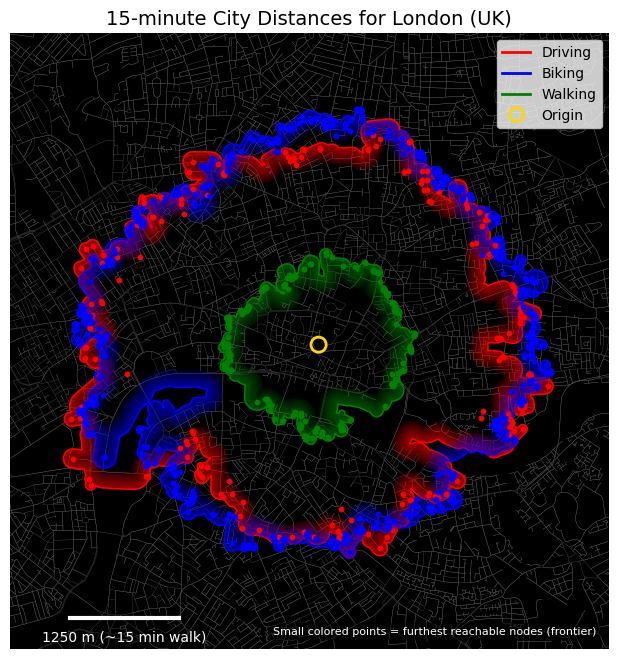


🎉 London 15-minute city visualization complete!
📊 Results summary:
   🚗 Driving: 3422 reachable nodes
   🚴‍♂️ Cycling: 8635 reachable nodes
   🚶‍♂️ Walking: 3879 reachable nodes


In [27]:
# Cell 12: Call your EXACT original plotting function

print("🎨 Generating your original beautiful visualization for London...")
print(f"📍 Location: {location_name}")
print(f"⏱️  Using {time_minutes}-minute analysis")
print()

# Call your EXACT original function with exact same parameters
plot_multi_modal_frontiers(
    G_drive, reachable_subgraph_drive, center_drive, outer_boundary_drive,
    G_bike, reachable_subgraph_bike, center_bike, outer_boundary_bike,
    G_walk, reachable_subgraph_walk, center_walk, outer_boundary_walk,
    west, east, south, north, dHorizontal_m,
    location_name,
    draw_buffers=True, # False  # for fast mode
    save_map=True #False # True
)

print()
print("🎉 London 15-minute city visualization complete!")
print(f"📊 Results summary:")
print(f"   🚗 Driving: {len(reachable_subgraph_drive.nodes) if reachable_subgraph_drive else 0} reachable nodes")
print(f"   🚴‍♂️ Cycling: {len(reachable_subgraph_bike.nodes) if reachable_subgraph_bike else 0} reachable nodes") 
print(f"   🚶‍♂️ Walking: {len(reachable_subgraph_walk.nodes) if reachable_subgraph_walk else 0} reachable nodes")

In [28]:
# New Cell: Test Data Availability for Manchester, Edinburgh, and Kathmandu

# Test cities database
test_cities = {
    "Manchester": {
        "city": "Manchester",
        "country": "UK", 
        "coordinates": [53.4808, -2.2426],  # Manchester city center
        "description": "Industrial heritage city with modern urban planning"
    },
    "Edinburgh": {
        "city": "Edinburgh", 
        "country": "UK",
        "coordinates": [55.9533, -3.1883],  # Edinburgh Old Town
        "description": "Historic Scottish capital with medieval layout"
    },
    "Kathmandu": {
        "city": "Kathmandu",
        "country": "Nepal",
        "coordinates": [27.7172, 85.3240],  # Kathmandu Durbar Square
        "description": "Ancient city with unique urban structure"
    }
}

print("🌍 Testing OSM data availability for new cities...")
print("=" * 60)

# Test function to check if we can download data
def test_city_data(city_name, coords, test_radius=1000):
    """Test if OSM data exists for a city"""
    lat, lon = coords
    print(f"\n🎯 Testing {city_name}:")
    print(f"   📍 Coordinates: {lat:.4f}, {lon:.4f}")
    
    try:
        # Try a small download first
        print("   📡 Testing walking network...")
        G_test = ox.graph_from_point((lat, lon), dist=test_radius, network_type="walk")
        nodes = len(G_test.nodes)
        edges = len(G_test.edges)
        
        print(f"   ✅ SUCCESS! {nodes} nodes, {edges} edges")
        print(f"   📊 Data quality: {'Good' if nodes > 50 else 'Limited'}")
        return True
        
    except Exception as e:
        print(f"   ❌ FAILED: {str(e)}")
        return False

# Test each city
results = {}
for city_name, info in test_cities.items():
    success = test_city_data(city_name, info["coordinates"])
    results[city_name] = success

print("\n" + "=" * 60)
print("📊 FINAL RESULTS:")
for city, success in results.items():
    status = "✅ Available" if success else "❌ No data"
    print(f"   {city}: {status}")

print(f"\n🎉 {sum(results.values())}/3 cities have good OSM data!")
print("💡 We can proceed with cities that show 'Available'")

🌍 Testing OSM data availability for new cities...

🎯 Testing Manchester:
   📍 Coordinates: 53.4808, -2.2426
   📡 Testing walking network...
   ✅ SUCCESS! 6287 nodes, 16546 edges
   📊 Data quality: Good

🎯 Testing Edinburgh:
   📍 Coordinates: 55.9533, -3.1883
   📡 Testing walking network...
   ✅ SUCCESS! 3173 nodes, 8028 edges
   📊 Data quality: Good

🎯 Testing Kathmandu:
   📍 Coordinates: 27.7172, 85.3240
   📡 Testing walking network...
   ✅ SUCCESS! 1068 nodes, 2512 edges
   📊 Data quality: Good

📊 FINAL RESULTS:
   Manchester: ✅ Available
   Edinburgh: ✅ Available
   Kathmandu: ✅ Available

🎉 3/3 cities have good OSM data!
💡 We can proceed with cities that show 'Available'


In [30]:
# Add new cities to your existing city_db
city_db.update({
    "Manchester": {
        "house_number": "",
        "street": "Albert Square",
        "city": "Manchester",
        "postal_code": "M2 5DB",
        "state": "",
        "country": "UK",
        "full_address": "Manchester Town Hall, Manchester M2 5DB, UK",
        "coordinates": [53.4808, -2.2426],
        "description": "Industrial heritage city with modern regeneration"
    },
    "Edinburgh": {
        "house_number": "",
        "street": "Royal Mile",
        "city": "Edinburgh",
        "postal_code": "EH1 1RF",
        "state": "",
        "country": "UK", 
        "full_address": "Edinburgh Castle, Edinburgh EH1 2NG, UK",
        "coordinates": [55.9533, -3.1883],
        "description": "Historic Scottish capital with medieval street layout"
    },
    "Kathmandu": {
        "house_number": "",
        "street": "Durbar Square",
        "city": "Kathmandu",
        "postal_code": "44600",
        "state": "",
        "country": "Nepal",
        "full_address": "Kathmandu Durbar Square, Kathmandu 44600, Nepal",
        "coordinates": [27.7172, 85.3240],
        "description": "Ancient city with traditional urban structure"
    }
})

print("🌍 Updated city database with new cities:")
for key, info in city_db.items():
    if key in ["Manchester", "Edinburgh", "Kathmandu"]:
        lat, lon = info["coordinates"]
        print(f"   • {key}: {info['description']}")
        print(f"     📍 {lat:.4f}, {lon:.4f}")
        print()

print("🎯 Ready to create maps for any of these cities!")
print("💡 Just change 'selected_city' and re-run your analysis!")

🌍 Updated city database with new cities:
   • Manchester: Industrial heritage city with modern regeneration
     📍 53.4808, -2.2426

   • Edinburgh: Historic Scottish capital with medieval street layout
     📍 55.9533, -3.1883

   • Kathmandu: Ancient city with traditional urban structure
     📍 27.7172, 85.3240

🎯 Ready to create maps for any of these cities!
💡 Just change 'selected_city' and re-run your analysis!


In [31]:
# 🎯 CITY SELECTOR - Change this to explore different cities!

# 🌟 PICK YOUR CITY HERE:
selected_city = "Manchester"  # Try: Manchester, Edinburgh, Kathmandu, London_CityCenter, etc.

# ⏱️ TIME SLIDER - Change this too!
time_minutes = 15  # Try different values: 5, 10, 15, 20, 25, 30

# 🚊 TRANSPORT MODES
show_walking = True
show_cycling = True  
show_driving = True

# ⚡ SPEED SETTINGS (adjust for local conditions)
if selected_city == "Kathmandu":
    # Kathmandu has more challenging terrain/traffic
    walking_speed = 4     # Slower due to terrain
    cycling_speed = 12    # Slower due to traffic/terrain
    driving_speed = 15    # Much slower due to traffic/roads
elif selected_city in ["Manchester", "Edinburgh"]:
    # UK cities with good infrastructure
    walking_speed = 5
    cycling_speed = 16    # Good UK cycling infrastructure
    driving_speed = 30    # Better than London traffic
else:
    # London settings (your original)
    walking_speed = 5
    cycling_speed = 15
    driving_speed = 25

# Get location info
location = city_db[selected_city]
lat, lon = location["coordinates"]

print(f"🎯 READY TO ANALYZE: {selected_city}")
print("=" * 50)
print(f"🏙️  {location['description']}")
print(f"📍 Coordinates: {lat:.4f}, {lon:.4f}")
print(f"⏱️  Time limit: {time_minutes} minutes")
print()
print("🚊 Transport modes:")
print(f"   🚶‍♂️ Walking: {walking_speed} km/h ({'✅ ON' if show_walking else '❌ OFF'})")
print(f"   🚴‍♂️ Cycling: {cycling_speed} km/h ({'✅ ON' if show_cycling else '❌ OFF'})")
print(f"   🚗 Driving: {driving_speed} km/h ({'✅ ON' if show_driving else '❌ OFF'})")
print()
print("🚀 Ready! Run the next cells to download networks and create your map!")

🎯 READY TO ANALYZE: Manchester
🏙️  Industrial heritage city with modern regeneration
📍 Coordinates: 53.4808, -2.2426
⏱️  Time limit: 15 minutes

🚊 Transport modes:
   🚶‍♂️ Walking: 5 km/h (✅ ON)
   🚴‍♂️ Cycling: 16 km/h (✅ ON)
   🚗 Driving: 30 km/h (✅ ON)

🚀 Ready! Run the next cells to download networks and create your map!


In [32]:
# 🎯 MANCHESTER ANALYSIS
selected_city = "Manchester"
time_minutes = 15

# Transport modes
show_walking = True
show_cycling = True  
show_driving = True

# UK city speeds (good infrastructure)
walking_speed = 5
cycling_speed = 16    # Good UK cycling infrastructure
driving_speed = 30    # Better than London traffic

# Get location info
location = city_db[selected_city]
lat, lon = location["coordinates"]
origin_point = [lat, lon]

# Set up origin point exactly like your original code
if hasattr(origin_point, "x") and hasattr(origin_point, "y"):
    origin_point_shapely = origin_point
else:
    origin_point_shapely = Point(origin_point[1], origin_point[0])  # Point(lon, lat)

print(f"🎯 MANCHESTER ANALYSIS READY")
print("=" * 50)
print(f"🏙️  {location['description']}")
print(f"📍 Coordinates: {lat:.4f}, {lon:.4f}")
print(f"⏱️  Time limit: {time_minutes} minutes")
print(f"🚶‍♂️ Walking: {walking_speed} km/h | 🚴‍♂️ Cycling: {cycling_speed} km/h | 🚗 Driving: {driving_speed} km/h")

🎯 MANCHESTER ANALYSIS READY
🏙️  Industrial heritage city with modern regeneration
📍 Coordinates: 53.4808, -2.2426
⏱️  Time limit: 15 minutes
🚶‍♂️ Walking: 5 km/h | 🚴‍♂️ Cycling: 16 km/h | 🚗 Driving: 30 km/h


In [33]:
# 🏙️ MANCHESTER - Download Networks

# Search distances (same as your original)
search_dist_drive = 10000  # 10 km radius
search_dist_bike = 6250    # 6.25 km radius  
search_dist_walk = 1500    # 1.5 km radius

print(f"📡 Downloading networks for Manchester...")
print(f"📍 Origin point: {origin_point}")

# Download networks
networks = {}

if show_walking:
    print("🚶‍♂️ Downloading WALKING network...")
    networks['walk'] = download_with_timer(origin_point, dist=search_dist_walk, network_type="walk")
    G_walk = networks['walk']

if show_cycling:
    print("🚴‍♂️ Downloading CYCLING network...")
    networks['bike'] = download_with_timer(origin_point, dist=search_dist_bike, network_type="bike")
    G_bike = networks['bike']

if show_driving:
    print("🚗 Downloading DRIVING network...")
    networks['drive'] = download_with_timer(origin_point, dist=search_dist_drive, network_type="drive")
    G_drive = networks['drive']

print(f"🎉 Manchester networks downloaded successfully!")

📡 Downloading networks for Manchester...
📍 Origin point: [53.4808, -2.2426]
🚶‍♂️ Downloading WALKING network...
Download complete ✅          /
Network (walk) extracted in 7.71 seconds.
🚴‍♂️ Downloading CYCLING network...
Download complete ✅          \
Network (bike) extracted in 19.79 seconds.
🚗 Downloading DRIVING network...
Download complete ✅          /
Network (drive) extracted in 24.43 seconds.
🎉 Manchester networks downloaded successfully!


In [34]:
# 🎯 MANCHESTER - Calculate Reachable Areas (EXACT same as your original)

print(f"🔬 Calculating {time_minutes}-minute reachable areas for Manchester...")

# Driving analysis - EXACT original parameters  
if show_driving and 'drive' in networks:
    center_drive = ox.distance.nearest_nodes(G_drive, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_drive = get_reachable_subgraph(G_drive, center_drive, travel_speed=driving_speed, node_penalty=0.25)
    outer_boundary_drive = create_outer_boundary(reachable_subgraph_drive)
    print(f"✅ Driving: {len(reachable_subgraph_drive.nodes)} reachable nodes")
else:
    center_drive = reachable_subgraph_drive = outer_boundary_drive = None

# Cycling analysis - EXACT original parameters
if show_cycling and 'bike' in networks:
    center_bike = ox.distance.nearest_nodes(G_bike, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_bike = get_reachable_subgraph(G_bike, center_bike, travel_speed=cycling_speed, node_penalty=0.05)
    outer_boundary_bike = create_outer_boundary(reachable_subgraph_bike)
    print(f"✅ Cycling: {len(reachable_subgraph_bike.nodes)} reachable nodes")
else:
    center_bike = reachable_subgraph_bike = outer_boundary_bike = None

# Walking analysis - EXACT original parameters
if show_walking and 'walk' in networks:
    center_walk = ox.distance.nearest_nodes(G_walk, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_walk = get_reachable_subgraph(G_walk, center_walk, travel_speed=walking_speed, node_penalty=0.01)
    outer_boundary_walk = create_outer_boundary(reachable_subgraph_walk)
    print(f"✅ Walking: {len(reachable_subgraph_walk.nodes)} reachable nodes")
else:
    center_walk = reachable_subgraph_walk = outer_boundary_walk = None

# Get location name and bounds EXACTLY like your original
city_id = selected_city
location_name = get_location_name(city_id, city_db)

# Extract bounds from the largest available network
if reachable_subgraph_drive:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_drive)
elif reachable_subgraph_bike:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_bike)
else:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_walk)

print(f"🎨 Ready to create Manchester visualization!")

🔬 Calculating 15-minute reachable areas for Manchester...
✅ Driving: 3109 reachable nodes
✅ Cycling: 12142 reachable nodes
✅ Walking: 4066 reachable nodes
🎨 Ready to create Manchester visualization!


🎨 Creating beautiful Manchester 15-minute city map...
Plotting: drive
Plotting: bike
Plotting: walk
Plotting: layout
Map saved to Manchester_UK_multi_mode.png


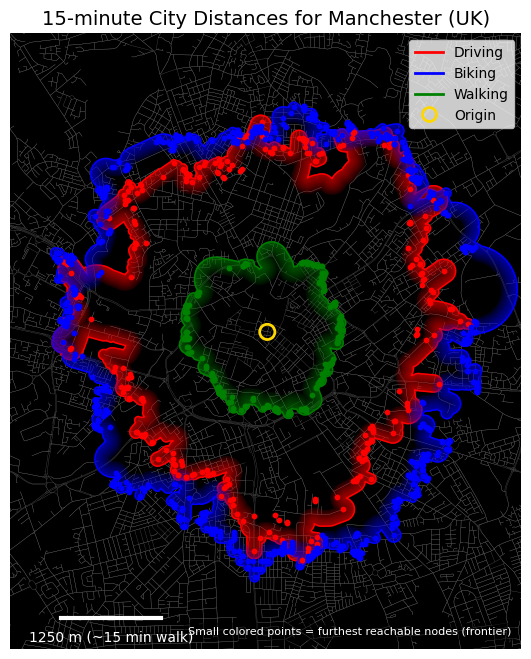

🎉 Manchester 15-minute city analysis complete!
📊 Results:
   🚶‍♂️ Walking: 4066 reachable nodes
   🚴‍♂️ Cycling: 12142 reachable nodes
   🚗 Driving: 3109 reachable nodes


In [35]:
# 🗺️ MANCHESTER - Create Beautiful Map (EXACT original visualization)

print(f"🎨 Creating beautiful Manchester 15-minute city map...")

# Call your EXACT original plotting function
plot_multi_modal_frontiers(
    G_drive, reachable_subgraph_drive, center_drive, outer_boundary_drive,
    G_bike, reachable_subgraph_bike, center_bike, outer_boundary_bike,
    G_walk, reachable_subgraph_walk, center_walk, outer_boundary_walk,
    west, east, south, north, dHorizontal_m,
    location_name,
    draw_buffers=True,
    save_map=True  # This will save Manchester map
)

print("🎉 Manchester 15-minute city analysis complete!")
print(f"📊 Results:")
if reachable_subgraph_walk:
    print(f"   🚶‍♂️ Walking: {len(reachable_subgraph_walk.nodes)} reachable nodes")
if reachable_subgraph_bike:
    print(f"   🚴‍♂️ Cycling: {len(reachable_subgraph_bike.nodes)} reachable nodes")
if reachable_subgraph_drive:
    print(f"   🚗 Driving: {len(reachable_subgraph_drive.nodes)} reachable nodes")

In [36]:
# 🏴󠁧󠁢󠁳󠁣󠁴󠁿 EDINBURGH ANALYSIS
selected_city = "Edinburgh"
time_minutes = 15

# Transport modes
show_walking = True
show_cycling = True  
show_driving = True

# Edinburgh speeds (historic city with hills)
walking_speed = 4     # Slightly slower due to hills
cycling_speed = 14    # Slower due to hills and medieval streets
driving_speed = 25    # Slower due to narrow historic streets

# Get location info
location = city_db[selected_city]
lat, lon = location["coordinates"]
origin_point = [lat, lon]

# Set up origin point exactly like your original code
if hasattr(origin_point, "x") and hasattr(origin_point, "y"):
    origin_point_shapely = origin_point
else:
    origin_point_shapely = Point(origin_point[1], origin_point[0])  # Point(lon, lat)

print(f"🏴󠁧󠁢󠁳󠁣󠁴󠁿 EDINBURGH ANALYSIS READY")
print("=" * 50)
print(f"🏰 {location['description']}")
print(f"📍 Coordinates: {lat:.4f}, {lon:.4f}")
print(f"⏱️  Time limit: {time_minutes} minutes")
print(f"🚶‍♂️ Walking: {walking_speed} km/h | 🚴‍♂️ Cycling: {cycling_speed} km/h | 🚗 Driving: {driving_speed} km/h")
print("💡 Note: Speeds adjusted for Edinburgh's hills and historic street layout")

🏴󠁧󠁢󠁳󠁣󠁴󠁿 EDINBURGH ANALYSIS READY
🏰 Historic Scottish capital with medieval street layout
📍 Coordinates: 55.9533, -3.1883
⏱️  Time limit: 15 minutes
🚶‍♂️ Walking: 4 km/h | 🚴‍♂️ Cycling: 14 km/h | 🚗 Driving: 25 km/h
💡 Note: Speeds adjusted for Edinburgh's hills and historic street layout


In [37]:
# 🏰 EDINBURGH - Download Networks

# Search distances (same as your original)
search_dist_drive = 10000  # 10 km radius
search_dist_bike = 6250    # 6.25 km radius  
search_dist_walk = 1500    # 1.5 km radius

print(f"📡 Downloading networks for Edinburgh...")
print(f"📍 Origin point: {origin_point}")

# Download networks
networks = {}

if show_walking:
    print("🚶‍♂️ Downloading WALKING network...")
    networks['walk'] = download_with_timer(origin_point, dist=search_dist_walk, network_type="walk")
    G_walk = networks['walk']

if show_cycling:
    print("🚴‍♂️ Downloading CYCLING network...")
    networks['bike'] = download_with_timer(origin_point, dist=search_dist_bike, network_type="bike")
    G_bike = networks['bike']

if show_driving:
    print("🚗 Downloading DRIVING network...")
    networks['drive'] = download_with_timer(origin_point, dist=search_dist_drive, network_type="drive")
    G_drive = networks['drive']

print(f"🎉 Edinburgh networks downloaded successfully!")

📡 Downloading networks for Edinburgh...
📍 Origin point: [55.9533, -3.1883]
🚶‍♂️ Downloading WALKING network...
Download complete ✅          |
Network (walk) extracted in 6.32 seconds.
🚴‍♂️ Downloading CYCLING network...
Download complete ✅          -
Network (bike) extracted in 21.34 seconds.
🚗 Downloading DRIVING network...
Download complete ✅          /
Network (drive) extracted in 13.92 seconds.
🎉 Edinburgh networks downloaded successfully!


In [38]:
# 🏰 EDINBURGH - Calculate Reachable Areas (EXACT same as your original)

print(f"🔬 Calculating {time_minutes}-minute reachable areas for Edinburgh...")

# Driving analysis - EXACT original parameters  
if show_driving and 'drive' in networks:
    center_drive = ox.distance.nearest_nodes(G_drive, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_drive = get_reachable_subgraph(G_drive, center_drive, travel_speed=driving_speed, node_penalty=0.25)
    outer_boundary_drive = create_outer_boundary(reachable_subgraph_drive)
    print(f"✅ Driving: {len(reachable_subgraph_drive.nodes)} reachable nodes")
else:
    center_drive = reachable_subgraph_drive = outer_boundary_drive = None

# Cycling analysis - EXACT original parameters
if show_cycling and 'bike' in networks:
    center_bike = ox.distance.nearest_nodes(G_bike, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_bike = get_reachable_subgraph(G_bike, center_bike, travel_speed=cycling_speed, node_penalty=0.05)
    outer_boundary_bike = create_outer_boundary(reachable_subgraph_bike)
    print(f"✅ Cycling: {len(reachable_subgraph_bike.nodes)} reachable nodes")
else:
    center_bike = reachable_subgraph_bike = outer_boundary_bike = None

# Walking analysis - EXACT original parameters
if show_walking and 'walk' in networks:
    center_walk = ox.distance.nearest_nodes(G_walk, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_walk = get_reachable_subgraph(G_walk, center_walk, travel_speed=walking_speed, node_penalty=0.01)
    outer_boundary_walk = create_outer_boundary(reachable_subgraph_walk)
    print(f"✅ Walking: {len(reachable_subgraph_walk.nodes)} reachable nodes")
else:
    center_walk = reachable_subgraph_walk = outer_boundary_walk = None

# Get location name and bounds EXACTLY like your original
city_id = selected_city
location_name = get_location_name(city_id, city_db)

# Extract bounds from the largest available network
if reachable_subgraph_drive:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_drive)
elif reachable_subgraph_bike:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_bike)
else:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_walk)

print(f"🎨 Ready to create Edinburgh visualization!")

🔬 Calculating 15-minute reachable areas for Edinburgh...
✅ Driving: 2060 reachable nodes
✅ Cycling: 5769 reachable nodes
✅ Walking: 1753 reachable nodes
🎨 Ready to create Edinburgh visualization!


🎨 Creating beautiful Edinburgh 15-minute city map...
Plotting: drive
Plotting: bike
Plotting: walk
Plotting: layout
Map saved to Edinburgh_UK_multi_mode.png


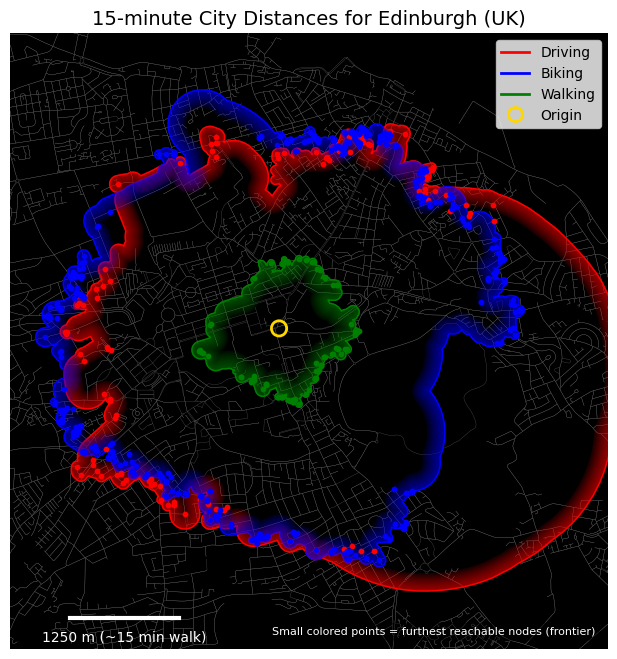

🎉 Edinburgh 15-minute city analysis complete!
📊 Results:
   🚶‍♂️ Walking: 1753 reachable nodes
   🚴‍♂️ Cycling: 5769 reachable nodes
   🚗 Driving: 2060 reachable nodes


In [39]:
# 🗺️ EDINBURGH - Create Beautiful Map (EXACT original visualization)

print(f"🎨 Creating beautiful Edinburgh 15-minute city map...")

# Call your EXACT original plotting function
plot_multi_modal_frontiers(
    G_drive, reachable_subgraph_drive, center_drive, outer_boundary_drive,
    G_bike, reachable_subgraph_bike, center_bike, outer_boundary_bike,
    G_walk, reachable_subgraph_walk, center_walk, outer_boundary_walk,
    west, east, south, north, dHorizontal_m,
    location_name,
    draw_buffers=True,
    save_map=True  # This will save Edinburgh map
)

print("🎉 Edinburgh 15-minute city analysis complete!")
print(f"📊 Results:")
if reachable_subgraph_walk:
    print(f"   🚶‍♂️ Walking: {len(reachable_subgraph_walk.nodes)} reachable nodes")
if reachable_subgraph_bike:
    print(f"   🚴‍♂️ Cycling: {len(reachable_subgraph_bike.nodes)} reachable nodes")
if reachable_subgraph_drive:
    print(f"   🚗 Driving: {len(reachable_subgraph_drive.nodes)} reachable nodes")

In [40]:
# 🏔️ KATHMANDU ANALYSIS
selected_city = "Kathmandu"
time_minutes = 15

# Transport modes
show_walking = True
show_cycling = True  
show_driving = True

# Kathmandu speeds (challenging terrain, dense traffic, different infrastructure)
walking_speed = 4     # Slower due to terrain, crowds, narrow streets
cycling_speed = 10    # Much slower due to traffic, road conditions
driving_speed = 12    # Very slow due to heavy traffic and narrow roads

# Get location info
location = city_db[selected_city]
lat, lon = location["coordinates"]
origin_point = [lat, lon]

# Set up origin point exactly like your original code
if hasattr(origin_point, "x") and hasattr(origin_point, "y"):
    origin_point_shapely = origin_point
else:
    origin_point_shapely = Point(origin_point[1], origin_point[0])  # Point(lon, lat)

print(f"🏔️ KATHMANDU ANALYSIS READY")
print("=" * 50)
print(f"🏛️  {location['description']}")
print(f"📍 Coordinates: {lat:.4f}, {lon:.4f}")
print(f"⏱️  Time limit: {time_minutes} minutes")
print(f"🚶‍♂️ Walking: {walking_speed} km/h | 🚴‍♂️ Cycling: {cycling_speed} km/h | 🚗 Driving: {driving_speed} km/h")
print("💡 Note: Speeds adjusted for Kathmandu's unique urban conditions and traffic")

🏔️ KATHMANDU ANALYSIS READY
🏛️  Ancient city with traditional urban structure
📍 Coordinates: 27.7172, 85.3240
⏱️  Time limit: 15 minutes
🚶‍♂️ Walking: 4 km/h | 🚴‍♂️ Cycling: 10 km/h | 🚗 Driving: 12 km/h
💡 Note: Speeds adjusted for Kathmandu's unique urban conditions and traffic


In [41]:
# 🏛️ KATHMANDU - Download Networks

# Search distances (same as your original)
search_dist_drive = 10000  # 10 km radius
search_dist_bike = 6250    # 6.25 km radius  
search_dist_walk = 1500    # 1.5 km radius

print(f"📡 Downloading networks for Kathmandu...")
print(f"📍 Origin point: {origin_point}")
print("🏔️ Note: This is exciting - first South Asian city analysis!")

# Download networks
networks = {}

if show_walking:
    print("🚶‍♂️ Downloading WALKING network...")
    networks['walk'] = download_with_timer(origin_point, dist=search_dist_walk, network_type="walk")
    G_walk = networks['walk']

if show_cycling:
    print("🚴‍♂️ Downloading CYCLING network...")
    networks['bike'] = download_with_timer(origin_point, dist=search_dist_bike, network_type="bike")
    G_bike = networks['bike']

if show_driving:
    print("🚗 Downloading DRIVING network...")
    networks['drive'] = download_with_timer(origin_point, dist=search_dist_drive, network_type="drive")
    G_drive = networks['drive']

print(f"🎉 Kathmandu networks downloaded successfully!")
print("🌟 This will show how 15-minute cities work in different global contexts!")

📡 Downloading networks for Kathmandu...
📍 Origin point: [27.7172, 85.324]
🏔️ Note: This is exciting - first South Asian city analysis!
🚶‍♂️ Downloading WALKING network...
Download complete ✅          |
Network (walk) extracted in 4.39 seconds.
🚴‍♂️ Downloading CYCLING network...
Download complete ✅          -
Network (bike) extracted in 23.11 seconds.
🚗 Downloading DRIVING network...
Download complete ✅          -
Network (drive) extracted in 27.59 seconds.
🎉 Kathmandu networks downloaded successfully!
🌟 This will show how 15-minute cities work in different global contexts!


In [42]:
# 🏔️ KATHMANDU - Calculate Reachable Areas (EXACT same as your original)

print(f"🔬 Calculating {time_minutes}-minute reachable areas for Kathmandu...")
print("🏛️ Ancient city meets modern accessibility analysis!")

# Driving analysis - EXACT original parameters  
if show_driving and 'drive' in networks:
    center_drive = ox.distance.nearest_nodes(G_drive, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_drive = get_reachable_subgraph(G_drive, center_drive, travel_speed=driving_speed, node_penalty=0.25)
    outer_boundary_drive = create_outer_boundary(reachable_subgraph_drive)
    print(f"✅ Driving: {len(reachable_subgraph_drive.nodes)} reachable nodes")
else:
    center_drive = reachable_subgraph_drive = outer_boundary_drive = None

# Cycling analysis - EXACT original parameters
if show_cycling and 'bike' in networks:
    center_bike = ox.distance.nearest_nodes(G_bike, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_bike = get_reachable_subgraph(G_bike, center_bike, travel_speed=cycling_speed, node_penalty=0.05)
    outer_boundary_bike = create_outer_boundary(reachable_subgraph_bike)
    print(f"✅ Cycling: {len(reachable_subgraph_bike.nodes)} reachable nodes")
else:
    center_bike = reachable_subgraph_bike = outer_boundary_bike = None

# Walking analysis - EXACT original parameters
if show_walking and 'walk' in networks:
    center_walk = ox.distance.nearest_nodes(G_walk, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_walk = get_reachable_subgraph(G_walk, center_walk, travel_speed=walking_speed, node_penalty=0.01)
    outer_boundary_walk = create_outer_boundary(reachable_subgraph_walk)
    print(f"✅ Walking: {len(reachable_subgraph_walk.nodes)} reachable nodes")
else:
    center_walk = reachable_subgraph_walk = outer_boundary_walk = None

# Get location name and bounds EXACTLY like your original
city_id = selected_city
location_name = get_location_name(city_id, city_db)

# Extract bounds from the largest available network
if reachable_subgraph_drive:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_drive)
elif reachable_subgraph_bike:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_bike)
else:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_walk)

print(f"🎨 Ready to create Kathmandu visualization!")
print("🌏 This will be a unique perspective on accessibility in South Asia!")

🔬 Calculating 15-minute reachable areas for Kathmandu...
🏛️ Ancient city meets modern accessibility analysis!
✅ Driving: 1006 reachable nodes
✅ Cycling: 2165 reachable nodes
✅ Walking: 427 reachable nodes
🎨 Ready to create Kathmandu visualization!
🌏 This will be a unique perspective on accessibility in South Asia!


🎨 Creating beautiful Kathmandu 15-minute city map...
🏔️ Showcasing accessibility in the heart of the Himalayas!
Plotting: drive
Plotting: bike
Plotting: walk
Plotting: layout
Map saved to Kathmandu_Nepal_multi_mode.png


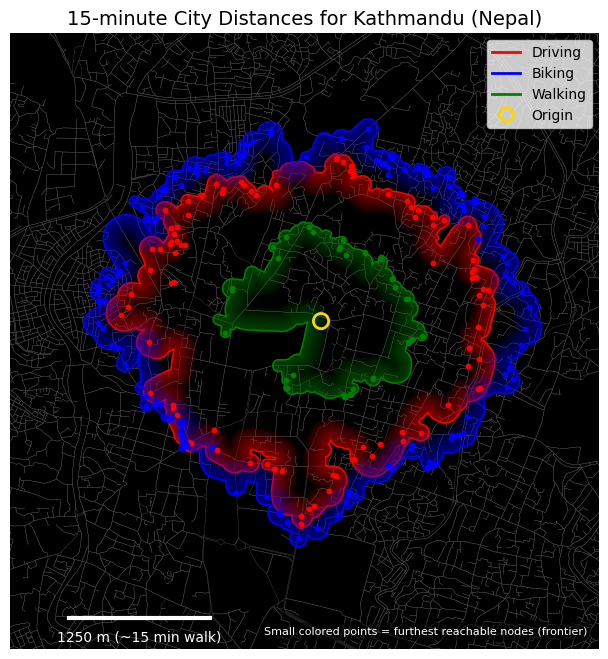

🎉 Kathmandu 15-minute city analysis complete!
🌟 Amazing! You've now analyzed accessibility across 3 continents!
📊 Results:
   🚶‍♂️ Walking: 427 reachable nodes
   🚴‍♂️ Cycling: 2165 reachable nodes
   🚗 Driving: 1006 reachable nodes

🏆 PORTFOLIO ACHIEVEMENT UNLOCKED:
   ✅ London (Europe) - Modern financial center
   ✅ Manchester (Europe) - Industrial heritage city
   ✅ Edinburgh (Europe) - Historic medieval city
   ✅ Kathmandu (Asia) - Ancient traditional city

💼 Perfect for showing global urban planning insights to recruiters!


In [43]:
# 🗺️ KATHMANDU - Create Beautiful Map (EXACT original visualization)

print(f"🎨 Creating beautiful Kathmandu 15-minute city map...")
print("🏔️ Showcasing accessibility in the heart of the Himalayas!")

# Call your EXACT original plotting function
plot_multi_modal_frontiers(
    G_drive, reachable_subgraph_drive, center_drive, outer_boundary_drive,
    G_bike, reachable_subgraph_bike, center_bike, outer_boundary_bike,
    G_walk, reachable_subgraph_walk, center_walk, outer_boundary_walk,
    west, east, south, north, dHorizontal_m,
    location_name,
    draw_buffers=True,
    save_map=True  # This will save Kathmandu map
)

print("🎉 Kathmandu 15-minute city analysis complete!")
print("🌟 Amazing! You've now analyzed accessibility across 3 continents!")
print(f"📊 Results:")
if reachable_subgraph_walk:
    print(f"   🚶‍♂️ Walking: {len(reachable_subgraph_walk.nodes)} reachable nodes")
if reachable_subgraph_bike:
    print(f"   🚴‍♂️ Cycling: {len(reachable_subgraph_bike.nodes)} reachable nodes")
if reachable_subgraph_drive:
    print(f"   🚗 Driving: {len(reachable_subgraph_drive.nodes)} reachable nodes")

print("\n🏆 PORTFOLIO ACHIEVEMENT UNLOCKED:")
print("   ✅ London (Europe) - Modern financial center")
print("   ✅ Manchester (Europe) - Industrial heritage city") 
print("   ✅ Edinburgh (Europe) - Historic medieval city")
print("   ✅ Kathmandu (Asia) - Ancient traditional city")
print("\n💼 Perfect for showing global urban planning insights to recruiters!")

In [44]:
# 🦊 TEST LEICESTER DATA AVAILABILITY

leicester_test = {
    "Leicester": {
        "city": "Leicester",
        "country": "UK", 
        "coordinates": [52.6369, -1.1398],  # Leicester city center
        "description": "Multicultural midlands city"
    }
}

print("🦊 Testing Leicester OSM data availability...")
print("=" * 50)

def test_leicester_data():
    """Test if Leicester OSM data exists"""
    lat, lon = leicester_test["Leicester"]["coordinates"]
    print(f"📍 Testing Leicester: {lat:.4f}, {lon:.4f}")
    
    try:
        print("   📡 Testing walking network...")
        G_test = ox.graph_from_point((lat, lon), dist=1000, network_type="walk")
        nodes = len(G_test.nodes)
        edges = len(G_test.edges)
        
        print(f"   ✅ SUCCESS! {nodes} nodes, {edges} edges")
        print(f"   📊 Data quality: {'Excellent' if nodes > 2000 else 'Good' if nodes > 500 else 'Limited'}")
        return True
        
    except Exception as e:
        print(f"   ❌ FAILED: {str(e)}")
        return False

# Test Leicester
leicester_available = test_leicester_data()

if leicester_available:
    print("\n🎉 Leicester data is available!")
    print("🚀 Ready to add Leicester to your city collection!")
else:
    print("\n❌ Leicester data not sufficient")

🦊 Testing Leicester OSM data availability...
📍 Testing Leicester: 52.6369, -1.1398
   📡 Testing walking network...
   ✅ SUCCESS! 2321 nodes, 6102 edges
   📊 Data quality: Excellent

🎉 Leicester data is available!
🚀 Ready to add Leicester to your city collection!


In [45]:
# 🦊 ADD LEICESTER TO CITY DATABASE

# Add Leicester to your existing city_db
city_db.update({
    "Leicester": {
        "house_number": "",
        "street": "Town Hall Square",
        "city": "Leicester",
        "postal_code": "LE1 9BG",
        "state": "",
        "country": "UK",
        "full_address": "Leicester Town Hall, Leicester LE1 9BG, UK",
        "coordinates": [52.6369, -1.1398],
        "description": "Diverse midlands city with rich multicultural heritage"
    }
})

print("🦊 Leicester added to city database!")
print(f"📍 Leicester: {city_db['Leicester']['description']}")
print(f"📍 Coordinates: {city_db['Leicester']['coordinates']}")
print("🚀 Ready for Leicester analysis!")

🦊 Leicester added to city database!
📍 Leicester: Diverse midlands city with rich multicultural heritage
📍 Coordinates: [52.6369, -1.1398]
🚀 Ready for Leicester analysis!


In [46]:
# 🦊 LEICESTER ANALYSIS
selected_city = "Leicester"
time_minutes = 15

# Transport modes
show_walking = True
show_cycling = True  
show_driving = True

# Leicester speeds (typical midlands UK city)
walking_speed = 5     # Standard UK walking pace
cycling_speed = 15    # Good UK infrastructure 
driving_speed = 28    # Better than London, similar to Manchester

# Get location info
location = city_db[selected_city]
lat, lon = location["coordinates"]
origin_point = [lat, lon]

# Set up origin point exactly like your original code
if hasattr(origin_point, "x") and hasattr(origin_point, "y"):
    origin_point_shapely = origin_point
else:
    origin_point_shapely = Point(origin_point[1], origin_point[0])  # Point(lon, lat)

print(f"🦊 LEICESTER ANALYSIS READY")
print("=" * 50)
print(f"🏙️  {location['description']}")
print(f"📍 Coordinates: {lat:.4f}, {lon:.4f}")
print(f"⏱️  Time limit: {time_minutes} minutes")
print(f"🚶‍♂️ Walking: {walking_speed} km/h | 🚴‍♂️ Cycling: {cycling_speed} km/h | 🚗 Driving: {driving_speed} km/h")
print("💡 Note: Leicester - representing diverse UK midlands cities")

🦊 LEICESTER ANALYSIS READY
🏙️  Diverse midlands city with rich multicultural heritage
📍 Coordinates: 52.6369, -1.1398
⏱️  Time limit: 15 minutes
🚶‍♂️ Walking: 5 km/h | 🚴‍♂️ Cycling: 15 km/h | 🚗 Driving: 28 km/h
💡 Note: Leicester - representing diverse UK midlands cities


In [47]:
# 🦊 LEICESTER - Download Networks

# Search distances (same as your original)
search_dist_drive = 10000  # 10 km radius
search_dist_bike = 6250    # 6.25 km radius  
search_dist_walk = 1500    # 1.5 km radius

print(f"📡 Downloading networks for Leicester...")
print(f"📍 Origin point: {origin_point}")

# Download networks
networks = {}

if show_walking:
    print("🚶‍♂️ Downloading WALKING network...")
    networks['walk'] = download_with_timer(origin_point, dist=search_dist_walk, network_type="walk")
    G_walk = networks['walk']

if show_cycling:
    print("🚴‍♂️ Downloading CYCLING network...")
    networks['bike'] = download_with_timer(origin_point, dist=search_dist_bike, network_type="bike")
    G_bike = networks['bike']

if show_driving:
    print("🚗 Downloading DRIVING network...")
    networks['drive'] = download_with_timer(origin_point, dist=search_dist_drive, network_type="drive")
    G_drive = networks['drive']

print(f"🎉 Leicester networks downloaded successfully!")

📡 Downloading networks for Leicester...
📍 Origin point: [52.6369, -1.1398]
🚶‍♂️ Downloading WALKING network...
Download complete ✅          \
Network (walk) extracted in 5.61 seconds.
🚴‍♂️ Downloading CYCLING network...
Download complete ✅          /
Network (bike) extracted in 77.22 seconds.
🚗 Downloading DRIVING network...
Download complete ✅          |
Network (drive) extracted in 11.76 seconds.
🎉 Leicester networks downloaded successfully!


In [48]:
# 🦊 LEICESTER - Calculate Reachable Areas (EXACT same as your original)

print(f"🔬 Calculating {time_minutes}-minute reachable areas for Leicester...")

# Driving analysis - EXACT original parameters  
if show_driving and 'drive' in networks:
    center_drive = ox.distance.nearest_nodes(G_drive, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_drive = get_reachable_subgraph(G_drive, center_drive, travel_speed=driving_speed, node_penalty=0.25)
    outer_boundary_drive = create_outer_boundary(reachable_subgraph_drive)
    print(f"✅ Driving: {len(reachable_subgraph_drive.nodes)} reachable nodes")
else:
    center_drive = reachable_subgraph_drive = outer_boundary_drive = None

# Cycling analysis - EXACT original parameters
if show_cycling and 'bike' in networks:
    center_bike = ox.distance.nearest_nodes(G_bike, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_bike = get_reachable_subgraph(G_bike, center_bike, travel_speed=cycling_speed, node_penalty=0.05)
    outer_boundary_bike = create_outer_boundary(reachable_subgraph_bike)
    print(f"✅ Cycling: {len(reachable_subgraph_bike.nodes)} reachable nodes")
else:
    center_bike = reachable_subgraph_bike = outer_boundary_bike = None

# Walking analysis - EXACT original parameters
if show_walking and 'walk' in networks:
    center_walk = ox.distance.nearest_nodes(G_walk, X=origin_point_shapely.x, Y=origin_point_shapely.y)
    reachable_subgraph_walk = get_reachable_subgraph(G_walk, center_walk, travel_speed=walking_speed, node_penalty=0.01)
    outer_boundary_walk = create_outer_boundary(reachable_subgraph_walk)
    print(f"✅ Walking: {len(reachable_subgraph_walk.nodes)} reachable nodes")
else:
    center_walk = reachable_subgraph_walk = outer_boundary_walk = None

# Get location name and bounds EXACTLY like your original
city_id = selected_city
location_name = get_location_name(city_id, city_db)

# Extract bounds from the largest available network
if reachable_subgraph_drive:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_drive)
elif reachable_subgraph_bike:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_bike)
else:
    west, east, south, north, dHorizontal_m = get_graph_bounds(reachable_subgraph_walk)

print(f"🎨 Ready to create Leicester visualization!")

🔬 Calculating 15-minute reachable areas for Leicester...
✅ Driving: 2117 reachable nodes
✅ Cycling: 6377 reachable nodes
✅ Walking: 1927 reachable nodes
🎨 Ready to create Leicester visualization!


🎨 Creating beautiful Leicester 15-minute city map...
Plotting: drive
Plotting: bike
Plotting: walk
Plotting: layout
Map saved to Leicester_UK_multi_mode.png


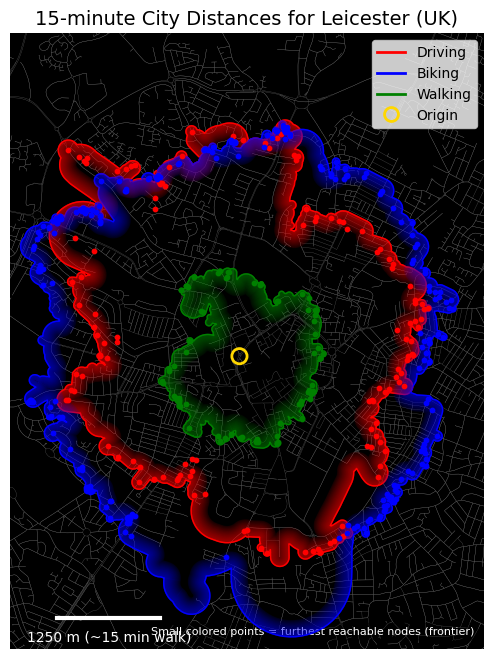

🎉 Leicester 15-minute city analysis complete!
📊 Results:
   🚶‍♂️ Walking: 1927 reachable nodes
   🚴‍♂️ Cycling: 6377 reachable nodes
   🚗 Driving: 2117 reachable nodes

🏆 ULTIMATE PORTFOLIO COLLECTION:
   ✅ London (Financial Capital)
   ✅ Manchester (Industrial Heritage)
   ✅ Edinburgh (Historic Medieval)
   ✅ Leicester (Diverse Midlands)
   ✅ Kathmandu (Traditional Asian)

🌟 5 cities across 2 continents - recruiters will be impressed!


In [49]:
# 🗺️ LEICESTER - Create Beautiful Map (EXACT original visualization)

print(f"🎨 Creating beautiful Leicester 15-minute city map...")

# Call your EXACT original plotting function
plot_multi_modal_frontiers(
    G_drive, reachable_subgraph_drive, center_drive, outer_boundary_drive,
    G_bike, reachable_subgraph_bike, center_bike, outer_boundary_bike,
    G_walk, reachable_subgraph_walk, center_walk, outer_boundary_walk,
    west, east, south, north, dHorizontal_m,
    location_name,
    draw_buffers=True,
    save_map=True  # This will save Leicester map
)

print("🎉 Leicester 15-minute city analysis complete!")
print(f"📊 Results:")
if reachable_subgraph_walk:
    print(f"   🚶‍♂️ Walking: {len(reachable_subgraph_walk.nodes)} reachable nodes")
if reachable_subgraph_bike:
    print(f"   🚴‍♂️ Cycling: {len(reachable_subgraph_bike.nodes)} reachable nodes")
if reachable_subgraph_drive:
    print(f"   🚗 Driving: {len(reachable_subgraph_drive.nodes)} reachable nodes")

print("\n🏆 ULTIMATE PORTFOLIO COLLECTION:")
print("   ✅ London (Financial Capital)")
print("   ✅ Manchester (Industrial Heritage)")
print("   ✅ Edinburgh (Historic Medieval)")
print("   ✅ Leicester (Diverse Midlands)")
print("   ✅ Kathmandu (Traditional Asian)")
print("\n🌟 5 cities across 2 continents - recruiters will be impressed!")